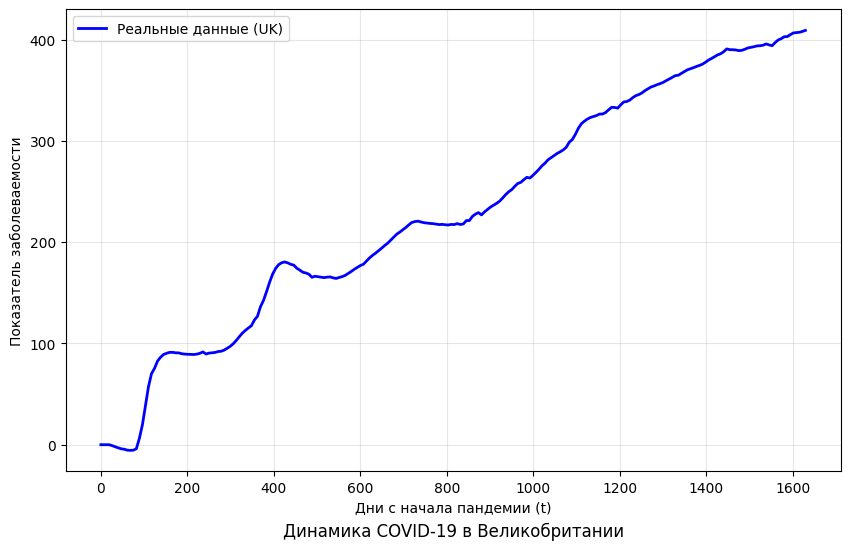

In [10]:
import numpy as np 
import matplotlib.pyplot as plt
import sympy as sp
from sympy import *
import pandas as pd
from scipy.optimize import curve_fit

df = pd.read_csv('Looking_only_for_UK.csv')
df = df[df['Entity'] == 'United Kingdom']
df = df.reset_index(drop=True)
#df = df.dropna(subset=['Confirmed COVID-19 deaths (per 100,000)']) 
df_clean = df.dropna(subset=['Central estimate'])
df['Day'] = pd.to_datetime(df['Day'], format='mixed')
df['Day_Number'] = (df['Day'] - df['Day'].min()).dt.days
df_clean = df.dropna(subset=['Central estimate', 'Day_Number']).copy()



#print(df.to_string())

t, beta, gamma, population, i_zero = symbols('t B Y N I_0')
I = sp.Function('I')(t)
r = beta - gamma

def growth_of_covid():
    equation = sp.Eq(I.diff(t), r*I)
    solution = sp.dsolve(equation, I)
    print(solution)
    return solution


def survived_covid():
    equation = sp.Eq(I.diff(t), r*I - (beta/population) * I**2)
    solution2 = sp.dsolve(equation, I)
    print(solution2)
    return solution2

def sis_model():
    equation = sp.Eq(I.diff(t), r*I - (beta/population) * I**2)
    solution3 = sp.dsolve(equation, I, iks={I.subs(t, 0): i_zero})
    print(solution3)
    return solution3


plt.rcParams['axes.titley'] = -0.2  
plt.rcParams['axes.titlepad'] = 20   


plt.figure(figsize=(10, 6))
plt.plot(df_clean['Day_Number'], df_clean['Central estimate'], label='Реальные данные (UK)', color='blue', linewidth=2)
plt.xlabel('Дни с начала пандемии (t)')
plt.ylabel('Показатель заболеваемости')
plt.title('Динамика COVID-19 в Великобритании')
plt.legend()
plt.grid(True, alpha=0.3)
#df.plot()

plt.show()
#growth_of_covid()
#survived_covid()
#sis_model()

Оцененное значение chi (B - Y): 0.0234


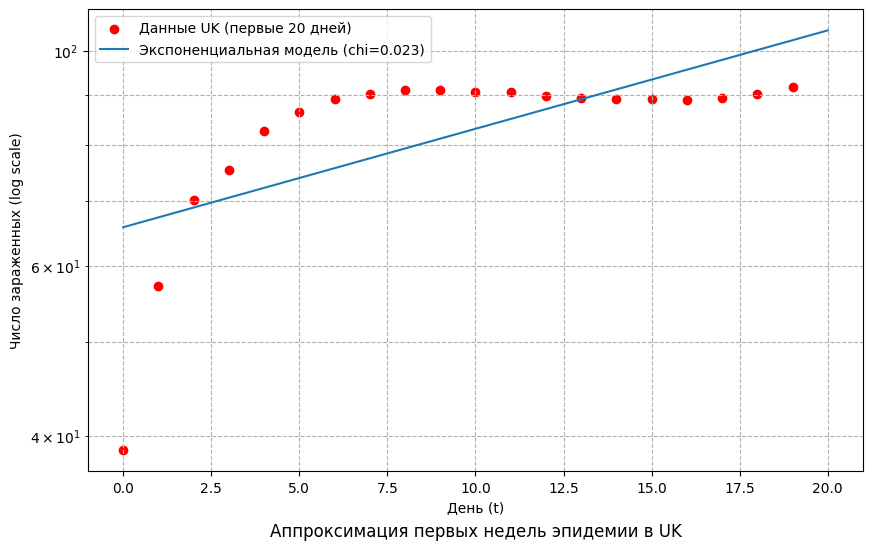

In [11]:
I0_threshold = 25
df_start = df_clean[df_clean['Central estimate'] >= I0_threshold].copy()
df_start['t'] = range(len(df_start))
df_analysis = df_start.head(20)


y = np.log(df_analysis['Central estimate'].values)
x = df_analysis['t'].values


coeffs = np.polyfit(x, y, 1)
chi_value = coeffs[0]
ln_I0 = coeffs[1]





print(f"Оцененное значение chi (B - Y): {chi_value:.4f}")

plt.figure(figsize=(10, 6))


plt.scatter(df_analysis['t'], df_analysis['Central estimate'], color='red', label='Данные UK (первые 20 дней)')


t_fine = np.linspace(0, 20, 100)
I_pred = np.exp(ln_I0 + chi_value * t_fine)
plt.plot(t_fine, I_pred, label=f'Экспоненциальная модель (chi={chi_value:.3f})')
plt.yscale('log')

plt.xlabel('День (t)')
plt.ylabel('Число зараженных (log scale)')
plt.title('Аппроксимация первых недель эпидемии в UK')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()


Оцененное значение I_inf: 396.08


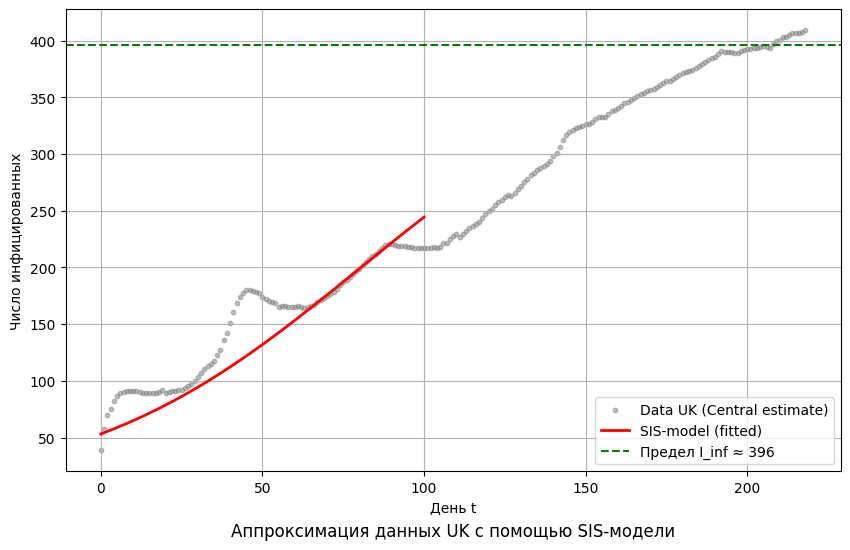

In [ ]:
def sis_model_func(t, I_inf, I0_fit):
    denominator = 1 + (I_inf / I0_fit - 1) * np.exp(-chi_value * t)
    return I_inf / denominator


df_longer = df_start.head(100) 
t_data = df_longer['t'].values
I_data = df_longer['Central estimate'].values


popt, pcov = curve_fit(sis_model_func, t_data, I_data, p0=[max(I_data), I_data[0]])

I_inf_fitted, I0_fitted = popt
print(f"Оцененное значение I_inf: {I_inf_fitted:.2f}")

plt.figure(figsize=(10, 6))


plt.scatter(t_data, I_data, label='Data UK (Central estimate)', color='grey', alpha=0.5, s=10)

# Наша модель после регрессии
t_range = np.linspace(0, 100, 200)
I_fitted_curve = sis_model_func(t_range, I_inf_fitted, I0_fitted)
plt.plot(t_range, I_fitted_curve, label='SIS-model (fitted)', color='red', linewidth=2)

# Линия потолка I_inf
plt.axhline(y=I_inf_fitted, color='green', linestyle='--', label=f'Предел I_inf ≈ {int(I_inf_fitted)}')

plt.title('Аппроксимация данных UK с помощью SIS-модели')
plt.xlabel('День t')
plt.ylabel('Число инфицированных')
plt.legend()
plt.grid(True)
plt.show()


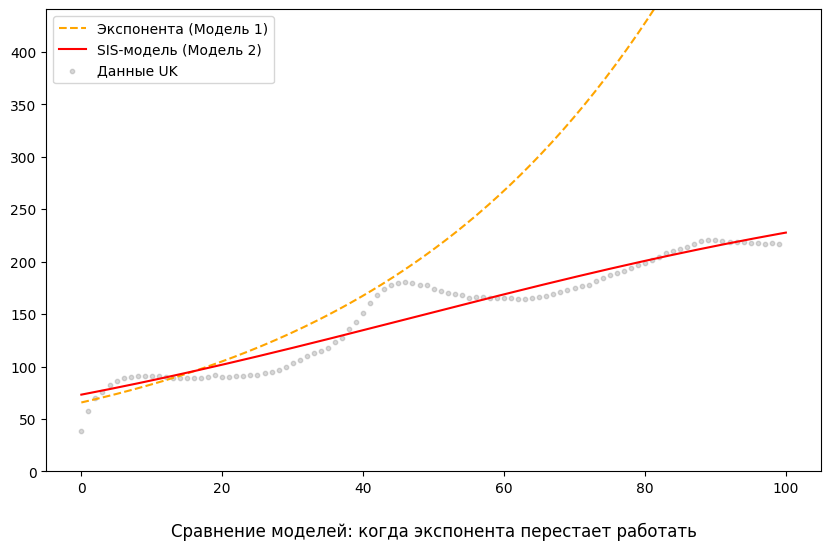

Погрешность L_inf: 36.43
Погрешность L_2: 135.69


In [9]:

residuals = I_data - sis_model_func(t_data, I_inf_fitted, I0_fitted)


l_inf = np.max(np.abs(residuals))


l_2 = np.sqrt(np.sum(residuals**2))


plt.figure(figsize=(10, 6))
t_ext = np.linspace(0, 100, 200)

I_exp = np.exp(ln_I0 + chi_value * t_ext) 

I_sis = sis_model_func(t_ext, I_inf_fitted, I0_fitted)

plt.plot(t_ext, I_exp, '--', label='Экспонента (Модель 1)', color='orange')
plt.plot(t_ext, I_sis, label='SIS-модель (Модель 2)', color='red')
plt.scatter(t_data, I_data, color='grey', alpha=0.3, s=10, label='Данные UK')
plt.ylim(0, I_inf_fitted * 1.5) 
plt.legend()
plt.title('Сравнение моделей: когда экспонента перестает работать')
plt.show()

#plt.figure(figsize=(10, 4))
#plt.bar(t_data, residuals, color='purple', alpha=0.6)
#plt.axhline(y=0, color='black', linestyle='-')
#plt.title('График остатков (отклонение данных от модели)')
#plt.ylabel('Ошибка (I_real - I_model)')

#plt.show()

print(f"Погрешность L_inf: {l_inf:.2f}")
print(f"Погрешность L_2: {l_2:.2f}")
